# ERCOT forecasting: portfolio walkthrough

This notebook reviews the completed SQL/Python study. Model fitting is in the eleven annotated blocks of `scripts/run_project.py`; see `reports/STEP_BY_STEP.md` for the full procedure. Run that pipeline before this notebook. No models are silently retrained here.

## 1. Locate the project

Use a portable project path and import analysis tools.

In [1]:
# Locate the repository from the project root or notebooks directory.
from pathlib import Path
import sqlite3
import pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd()
if ROOT.name=='notebooks': ROOT=ROOT.parent
assert (ROOT/'data/energy.sqlite').exists()


## 2. Audit with SQL

COUNT(column) excludes missing values. The annual total remains NULL when demand is incomplete.

In [2]:
# Query real SQL views created by sql/analysis.sql.
with sqlite3.connect(ROOT/'data/energy.sqlite') as con:
    display(pd.read_sql_query('SELECT * FROM quality_summary',con))
    display(pd.read_sql_query('SELECT * FROM annual_summary',con))


,calendar_days,observed_days,missing_demand_days,first_date,last_date
0,2557,2556,1,2019-01-01,2025-12-31


,year,calendar_days,observed_days,avg_daily_mwh,total_mwh
0,2019,365,365,1.051142e+06,383666740.0
1,2020,366,366,1.041042e+06,381021194.0
2,2021,365,365,1.075398e+06,392520240.0
3,2022,365,365,1.179748e+06,430608161.0
4,2023,365,365,1.224174e+06,446823428.0
5,2024,366,366,1.267161e+06,463781006.0
6,2025,365,364,1.339402e+06,NaN


## 3. Explore training data

Study trend, annual/weekly seasonality and weather associations using 2019–2023 only. Weather is an equal-city proxy, not a load-weighted measurement.

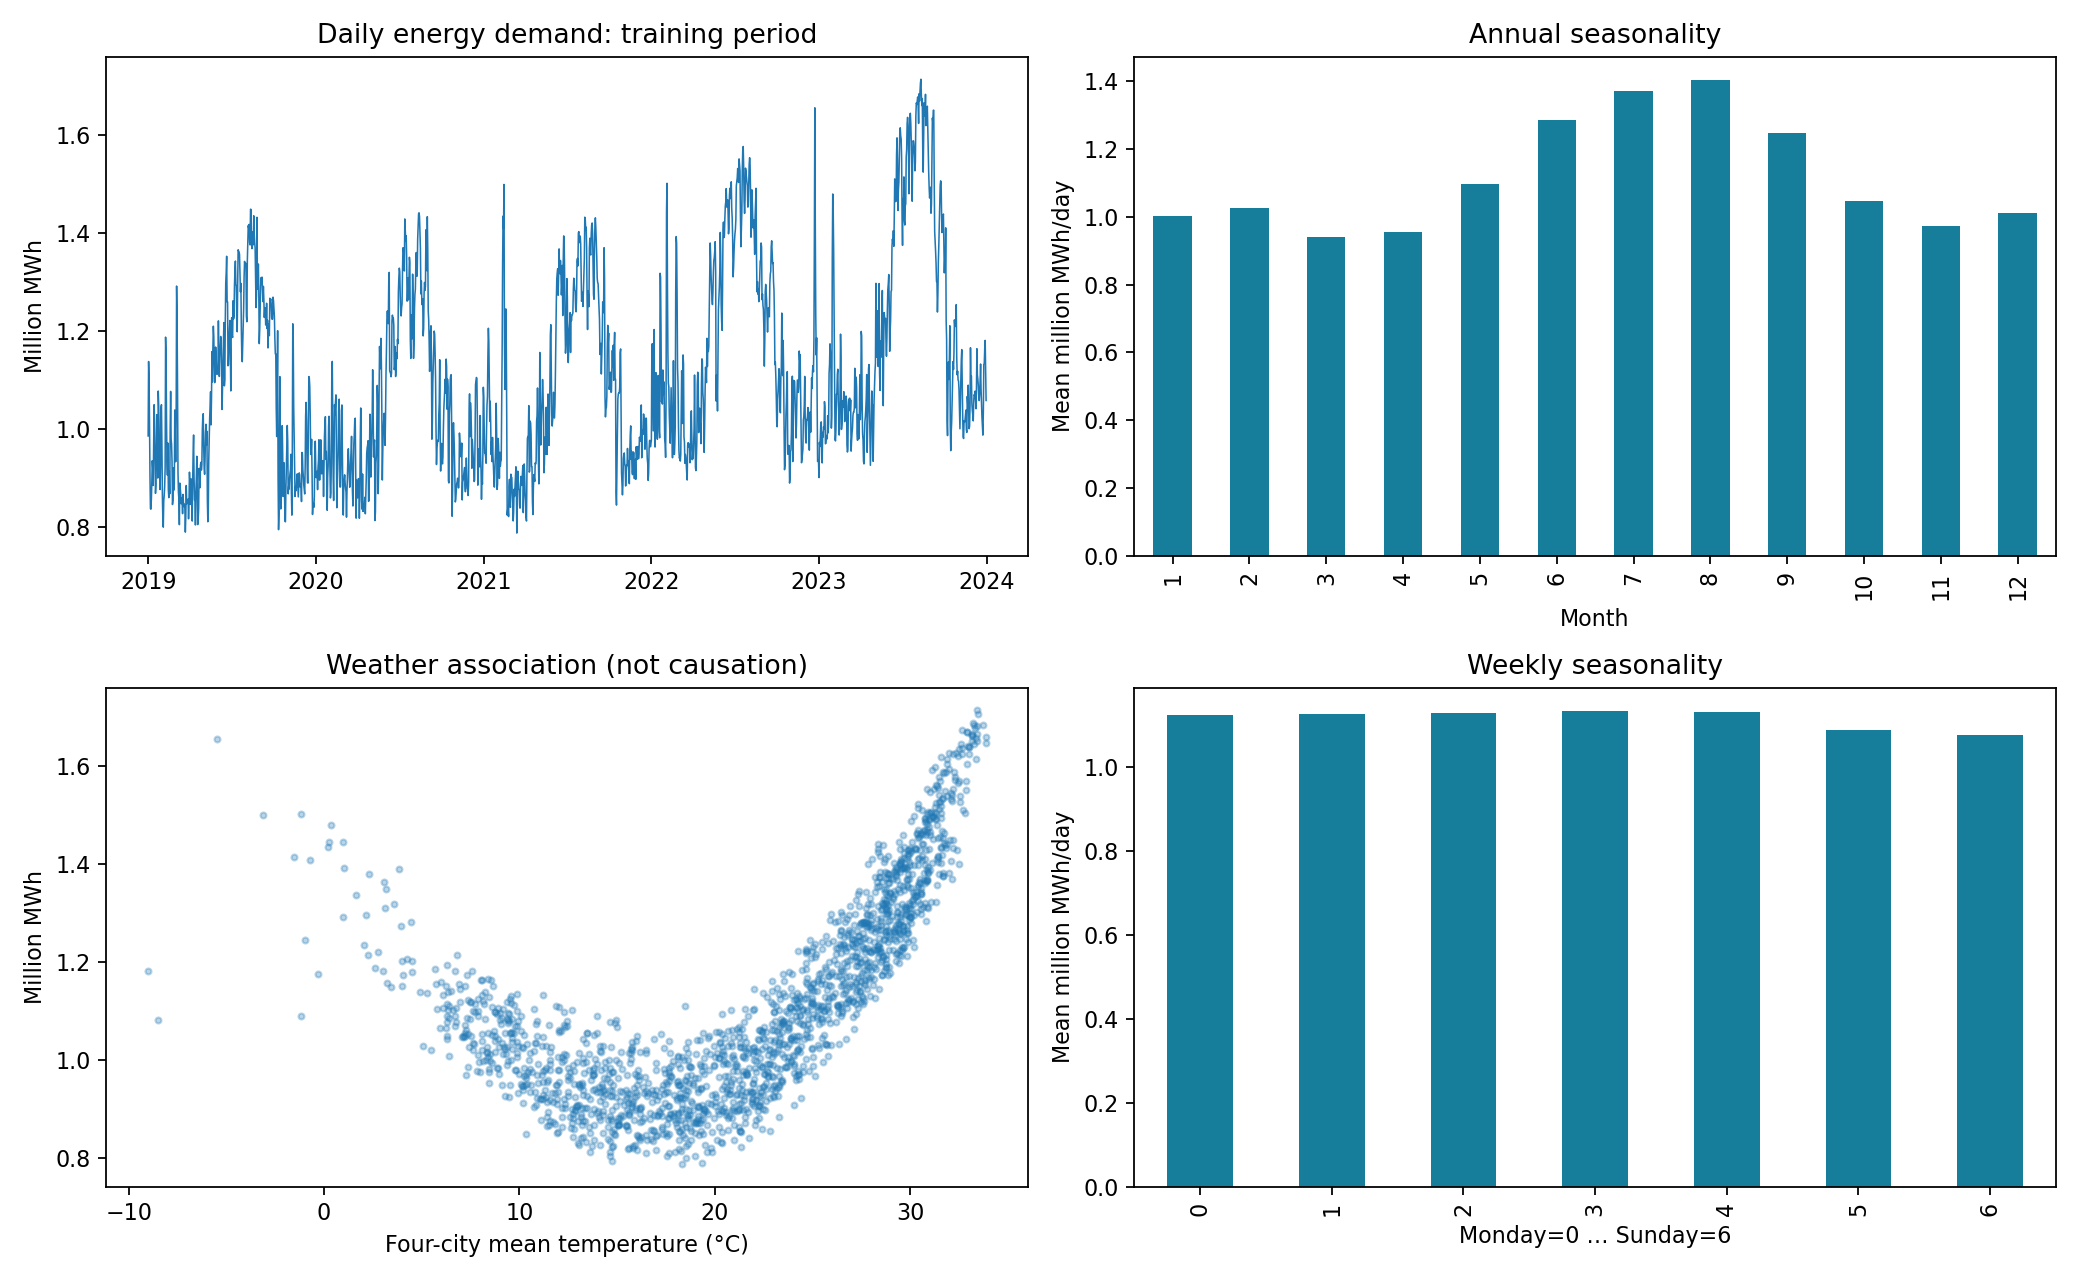

In [3]:
# Display the training-period figure saved by the completed analysis.
display(Image(filename=str(ROOT/'reports/figures/01_training_exploration.png')))


## 4. Select on validation

Direct models predict leads 1–31 from issue-date features. Select on 2024 MAE before inspecting 2025. The oracle uses realized future weather and is ineligible.

In [4]:
# Inspect validation evidence and reproduce the eligible selection.
v=pd.read_csv(ROOT/'reports/validation_metrics.csv')
display(v.round(2))
e=v[~v.model.str.startswith('oracle')]
display(e.loc[e.groupby('scale').mae_mwh.idxmin(),['scale','model','mae_mwh']])


,scale,model,n_periods,mae_mwh,rmse_mwh,wape_pct,bias_pct
0,daily,seasonal_naive,366,97381.17,135504.46,7.68,0.07
1,daily,ridge_calendar,366,72207.67,96805.09,5.70,0.01
2,daily,trees_calendar,366,111983.32,153817.06,8.84,2.46
3,daily,trees_weather,366,91541.76,128957.28,7.22,0.67
4,daily,oracle_weather_diagnostic,366,59900.25,72481.88,4.73,-4.25
5,monthly,seasonal_naive,12,3021726.42,3510529.16,7.82,-0.58
6,monthly,ridge_calendar,12,1991062.57,2370652.27,5.15,-0.14
7,monthly,trees_calendar,12,2667984.00,3282973.20,6.90,2.20
8,monthly,trees_weather,12,2024057.90,2517615.64,5.24,0.64
9,monthly,oracle_weather_diagnostic,12,1681465.15,1953323.65,4.35,-4.26


,scale,model,mae_mwh
1,daily,ridge_calendar,7.220767e+04
6,monthly,ridge_calendar,1.991063e+06
11,weekly,ridge_calendar,4.930125e+05


## 5. Evaluate frozen choices

Test on 2025 after refitting through 2024. Weekly/monthly paths are issued before each period. Missing December 5 invalidates its containing totals; only 11 months are scored.

,scale,model,n_periods,mae_mwh,rmse_mwh,wape_pct,bias_pct,mae_improvement_pct,interval_coverage_pct
0,daily,ridge_calendar,364,70423.90,99469.62,5.26,-1.04,31.83,89.56
1,monthly,ridge_calendar,11,1565637.05,2119687.81,3.82,-1.24,32.96,90.91
2,weekly,ridge_calendar,50,464707.67,669229.89,4.94,-1.37,22.77,92.00


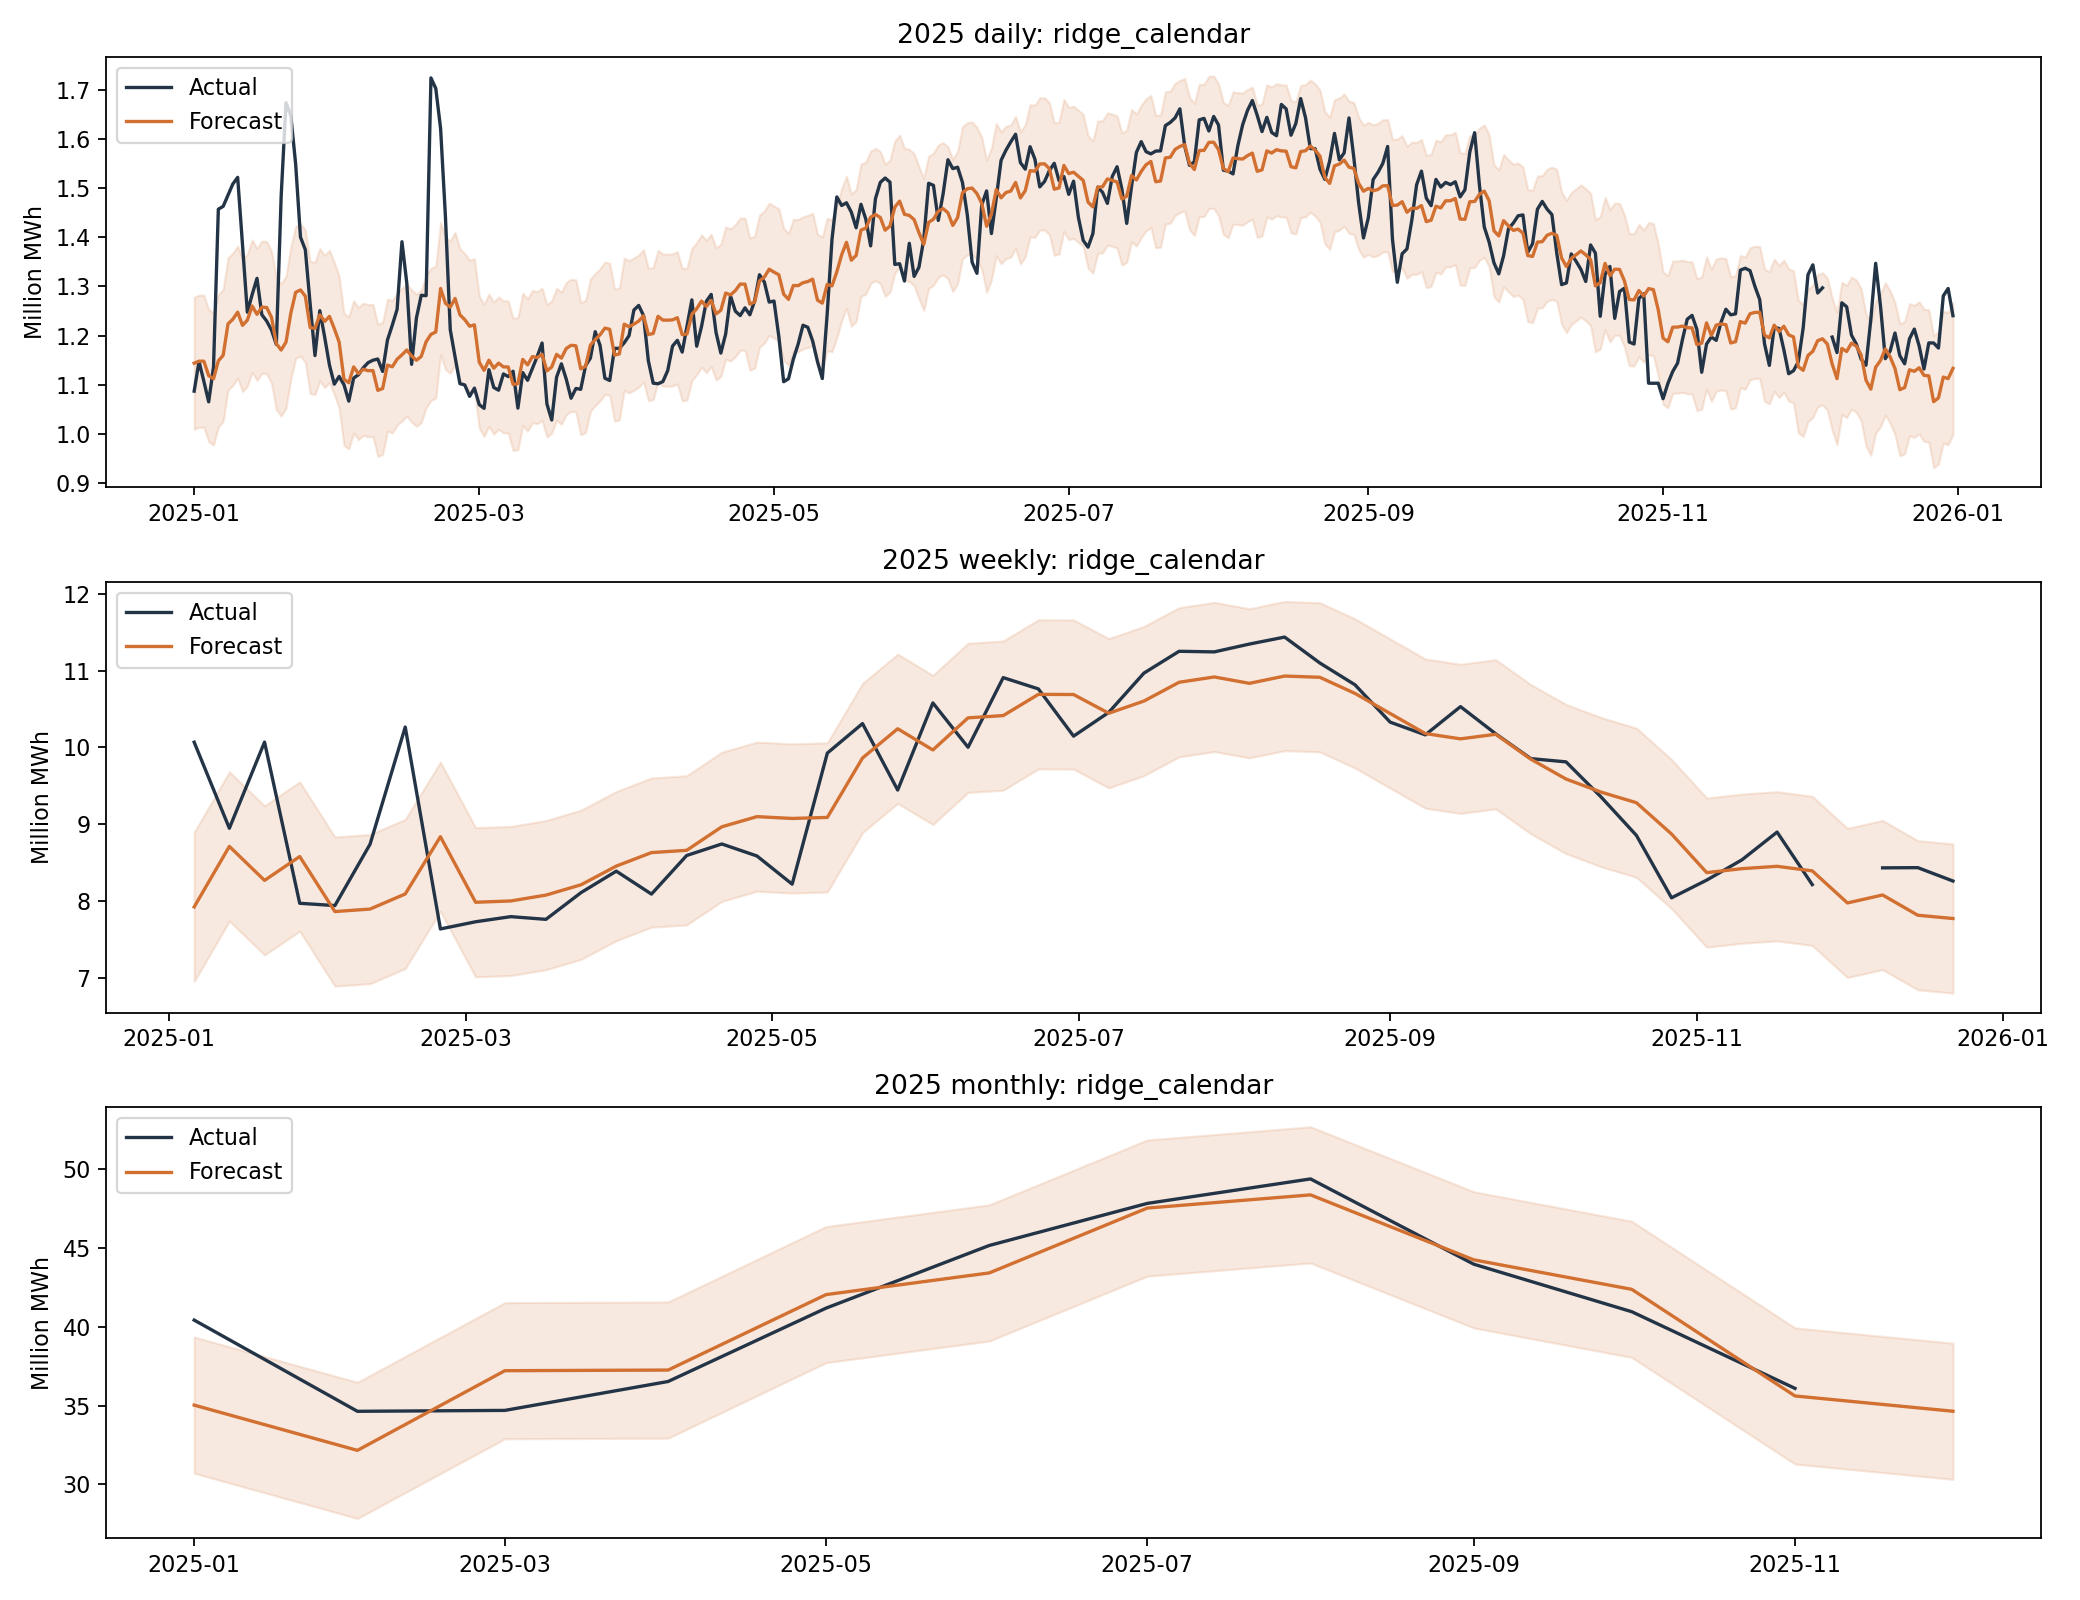

In [5]:
# Read measured scores without changing the selected models.
display(pd.read_csv(ROOT/'reports/selected_model_summary.csv').round(2))
display(Image(filename=str(ROOT/'reports/figures/02_test_forecasts.png')))


## 6. Inspect failures and lead times

The selected model misses sharp winter spikes. Next-day accuracy must not be attributed to every day in a 31-day forecast path. Approximate intervals have limited monthly calibration evidence.

In [6]:
# Show difficult next-day cases and distinguish individual forecast leads.
e=pd.read_csv(ROOT/'reports/largest_errors.csv')
display(e.loc[e.scale=='daily',['start','actual','prediction','abs_error_mwh']].round(0))
h=pd.read_csv(ROOT/'reports/test_metrics_by_horizon.csv')
display(h[(h.model=='ridge_calendar') & h.horizon_days.isin([1,7,14,31])].round(2))


,start,actual,prediction,abs_error_mwh
10,2025-02-19,1724708.0,1202444.0,522264.0
11,2025-02-20,1703254.0,1207246.0,496008.0
12,2025-01-20,1674205.0,1186566.0,487639.0
13,2025-01-21,1647906.0,1245601.0,402305.0
14,2025-02-21,1621566.0,1295903.0,325663.0


,horizon_days,model,n,mae_mwh,wape_pct
1,1,ridge_calendar,364,70423.90,5.26
31,7,ridge_calendar,358,82651.34,6.16
66,14,ridge_calendar,351,80645.20,6.01
151,31,ridge_calendar,334,77607.43,5.78


## 7. Deliver a dated forecast

January 2026 predictions are a historical snapshot issued December 31, 2025, not a current forecast. A common daily path reconciles to weekly/monthly totals. Recommend archived-weather evaluation before operational use; no financial savings are established.

In [7]:
# Inspect the dated outputs and the partial-week flags.
display(pd.read_csv(ROOT/'reports/snapshot_daily_january_2026.csv').head())
display(pd.read_csv(ROOT/'reports/snapshot_weekly_january_2026.csv'))
display(pd.read_csv(ROOT/'reports/snapshot_monthly_january_2026.csv'))


,origin,target,horizon,forecast_mwh
0,2025-12-31,2026-01-01,1,1.259020e+06
1,2025-12-31,2026-01-02,2,1.268003e+06
2,2025-12-31,2026-01-03,3,1.222843e+06
3,2025-12-31,2026-01-04,4,1.220717e+06
4,2025-12-31,2026-01-05,5,1.266918e+06


,week_start,days,forecast_mwh,complete_week
0,2025-12-29,4,4.970584e+06,False
1,2026-01-05,7,8.741018e+06,True
2,2026-01-12,7,8.690650e+06,True
3,2026-01-19,7,8.644548e+06,True
4,2026-01-26,6,7.436541e+06,False


,month,days,forecast_mwh,daily_path_model
0,2026-01,31,3.848334e+07,ridge_calendar
